# Customer Churn Prediction Using Machine Learning

## Problem Statement

Customer churn refers to customers discontinuing their subscription or service. Predicting customer churn can help organizations identify customers who may leave and take appropriate customer retention measures.

The objective of this project is to develop a machine learning classification model that predicts whether a customer will churn based on customer-related information such as age, tenure, usage frequency, support calls, payment delays, subscription type, contract length, total spending, and recent interaction history.


In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("customer_churn_dataset-training-master.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (440833, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [6]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (440833, 12)

Column Names:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Data Types:
CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object


In [7]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Duplicate Rows:
0


In [8]:
print("Churn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

Churn Percentage:
Churn
1.0    56.71072
0.0    43.28928
Name: proportion, dtype: float64


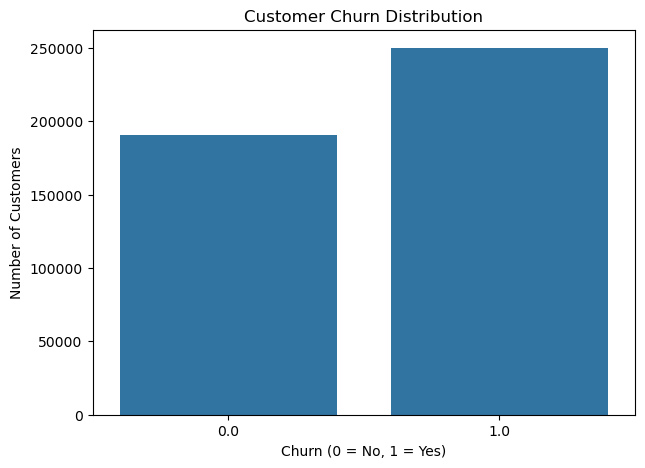

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

In [10]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [11]:
categorical_columns = [
    "Gender",
    "Subscription Type",
    "Contract Length"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


Gender:
Gender
Male      250252
Female    190580
Name: count, dtype: int64

Subscription Type:
Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

Contract Length:
Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64


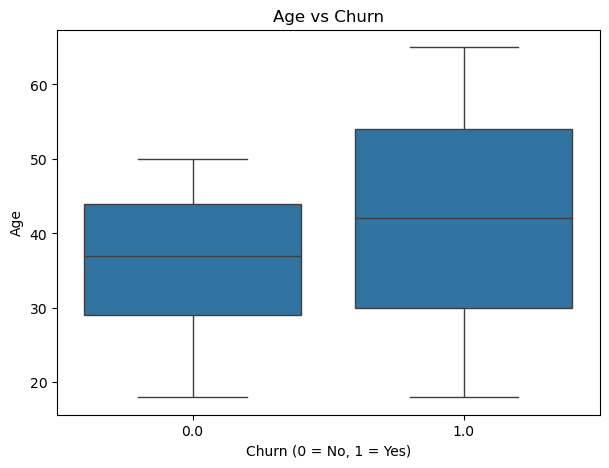

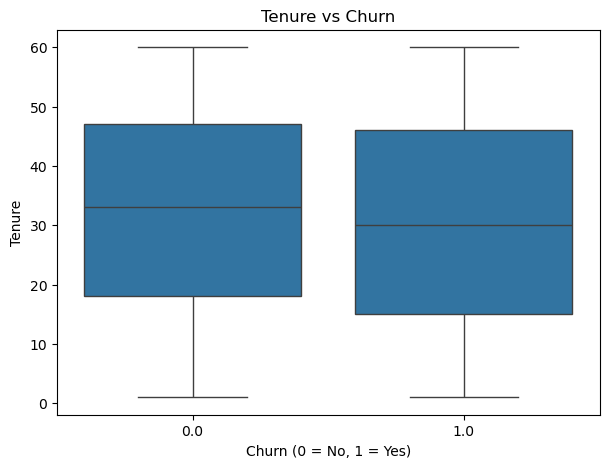

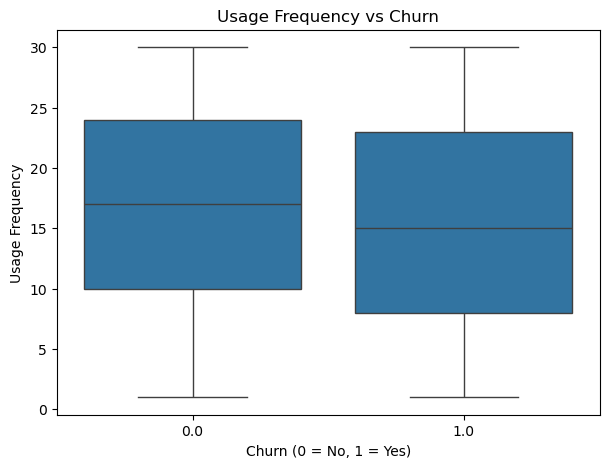

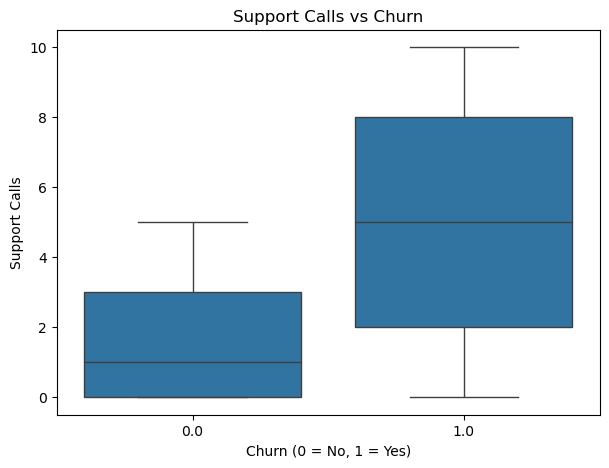

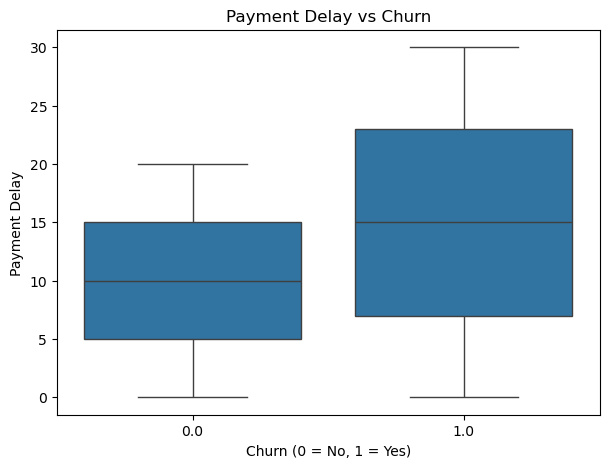

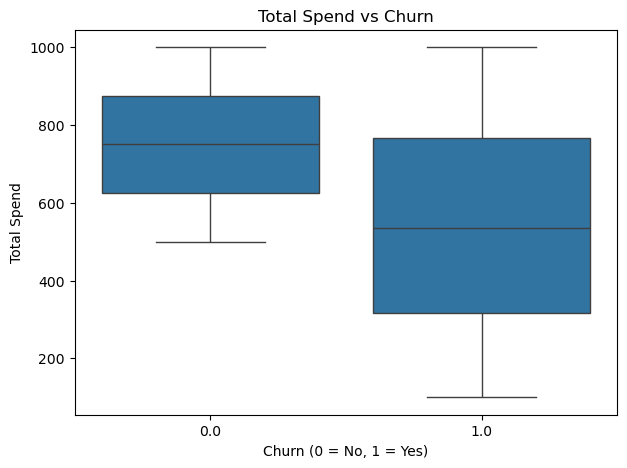

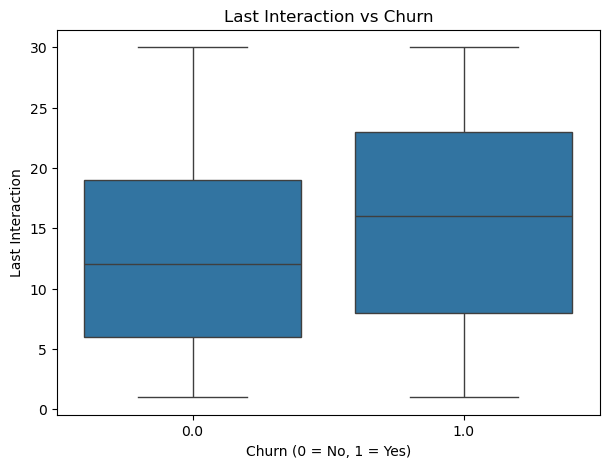

In [12]:
numerical_columns = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction"
]

for column in numerical_columns:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x="Churn", y=column)
    plt.title(f"{column} vs Churn")
    plt.xlabel("Churn (0 = No, 1 = Yes)")
    plt.ylabel(column)
    plt.show()

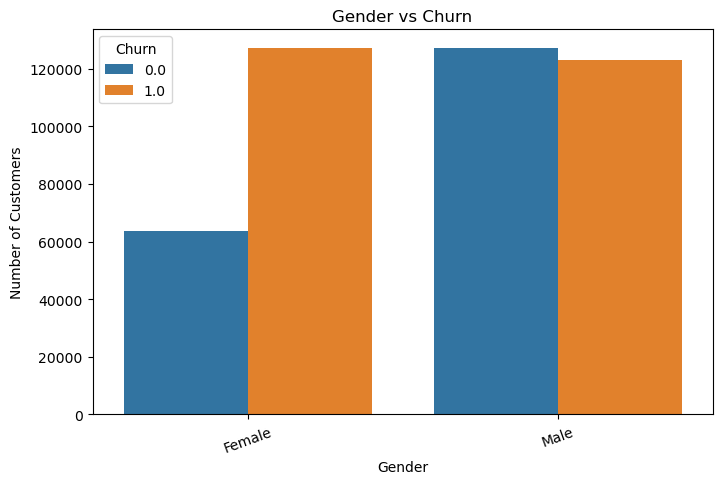

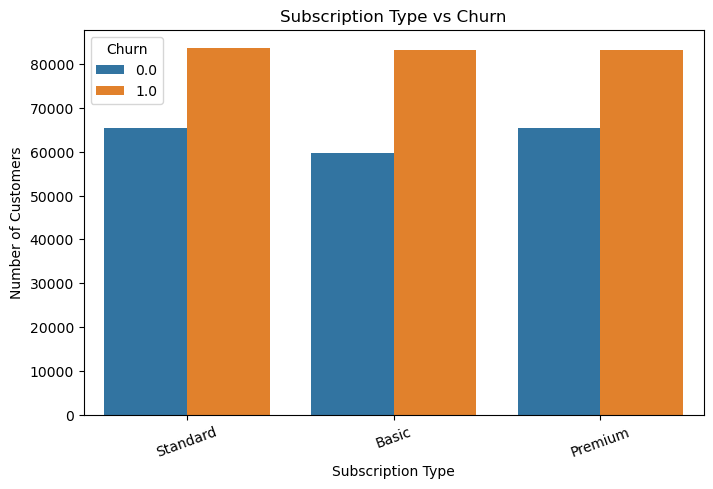

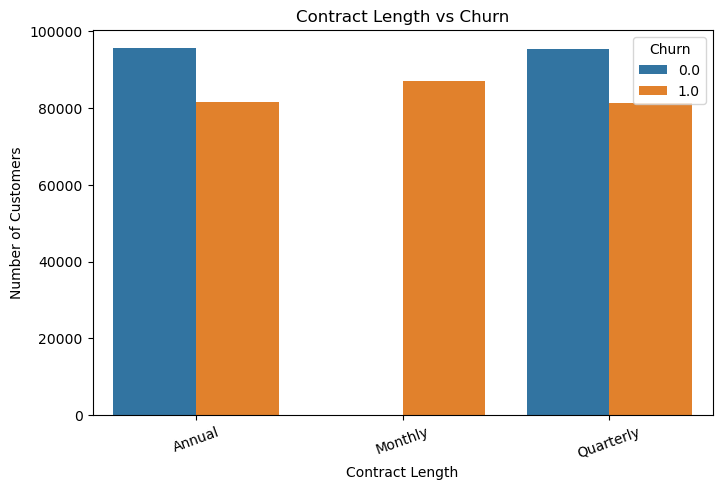

In [13]:
categorical_columns = [
    "Gender",
    "Subscription Type",
    "Contract Length"
]

for column in categorical_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=column, hue="Churn")
    plt.title(f"{column} vs Churn")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=20)
    plt.legend(title="Churn")
    plt.show()

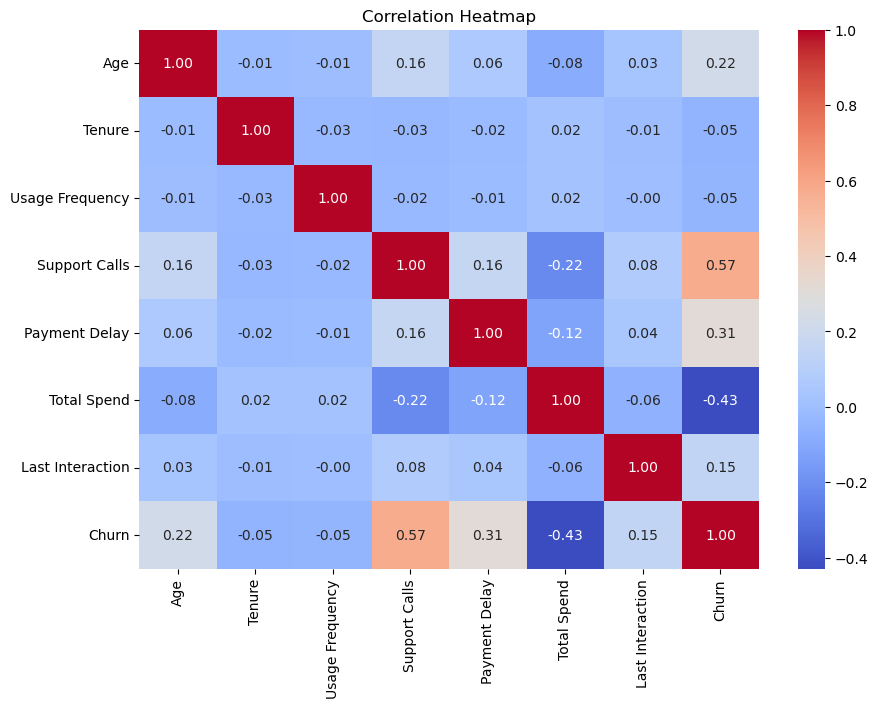

In [14]:
correlation = df[numerical_columns + ["Churn"]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
print("===== EDA SUMMARY =====")

print("\n1. Dataset Shape:")
print(df.shape)

print("\n2. Missing Values:")
print(df.isnull().sum().sum())

print("\n3. Duplicate Rows:")
print(df.duplicated().sum())

print("\n4. Churn Distribution:")
print(df["Churn"].value_counts())

print("\n5. Churn Percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

print("\n6. Numerical Feature Correlation with Churn:")
print(
    df[numerical_columns + ["Churn"]]
    .corr()["Churn"]
    .sort_values(ascending=False)
)

===== EDA SUMMARY =====

1. Dataset Shape:
(440833, 12)

2. Missing Values:
12

3. Duplicate Rows:
0

4. Churn Distribution:
Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

5. Churn Percentage:
Churn
1.0    56.71
0.0    43.29
Name: proportion, dtype: float64

6. Numerical Feature Correlation with Churn:
Churn               1.000000
Support Calls       0.574267
Payment Delay       0.312129
Age                 0.218394
Last Interaction    0.149616
Usage Frequency    -0.046101
Tenure             -0.051919
Total Spend        -0.429355
Name: Churn, dtype: float64


In [16]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Remove CustomerID
X = X.drop("CustomerID", axis=1)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Features shape: (440833, 10)
Target shape: (440833,)

Features:
['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']


In [17]:
# Identify feature types
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']

Categorical Features:
['Gender', 'Subscription Type', 'Contract Length']


In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [20]:
# Remove rows where the target variable is missing
missing_churn = df["Churn"].isna().sum()

print("Missing Churn values:", missing_churn)

df = df.dropna(subset=["Churn"]).copy()

print("New dataset shape:", df.shape)
print("Missing Churn values after cleaning:", df["Churn"].isna().sum())

Missing Churn values: 1
New dataset shape: (440832, 12)
Missing Churn values after cleaning: 0


In [21]:
# Recreate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Remove CustomerID
X = X.drop("CustomerID", axis=1)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (440832, 10)
Target shape: (440832,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (352665, 10)
Testing data: (88167, 10)


In [23]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']

Categorical Features:
['Gender', 'Subscription Type', 'Contract Length']


In [24]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [26]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions
y_pred_logistic = logistic_model.predict(X_test)
y_pred_rf = random_forest_model.predict(X_test)

# Logistic Regression metrics
logistic_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_logistic),
    "Precision": precision_score(y_test, y_pred_logistic),
    "Recall": recall_score(y_test, y_pred_logistic),
    "F1-Score": f1_score(y_test, y_pred_logistic)
}

# Random Forest metrics
rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf)
}

print("Logistic Regression:")
for metric, value in logistic_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nRandom Forest:")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

Logistic Regression:
Accuracy: 0.8934
Precision: 0.9234
Recall: 0.8855
F1-Score: 0.9040

Random Forest:
Accuracy: 0.9993
Precision: 0.9999
Recall: 0.9988
F1-Score: 0.9993


In [28]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [29]:
print("Duplicate Customer IDs:", df["CustomerID"].duplicated().sum())

Duplicate Customer IDs: 0


In [30]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [31]:
print("Duplicate Customer IDs:", df["CustomerID"].duplicated().sum())

Duplicate Customer IDs: 0


In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10],
    "classifier__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    random_forest_model,
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-Score:", grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV F1-Score: 0.9990340774688017


In [33]:
best_rf_model = grid_search.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test)

print("===== TUNED RANDOM FOREST =====")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_best_rf):.4f}")

===== TUNED RANDOM FOREST =====
Accuracy:  0.9993
Precision: 0.9999
Recall:    0.9988
F1-Score:  0.9994


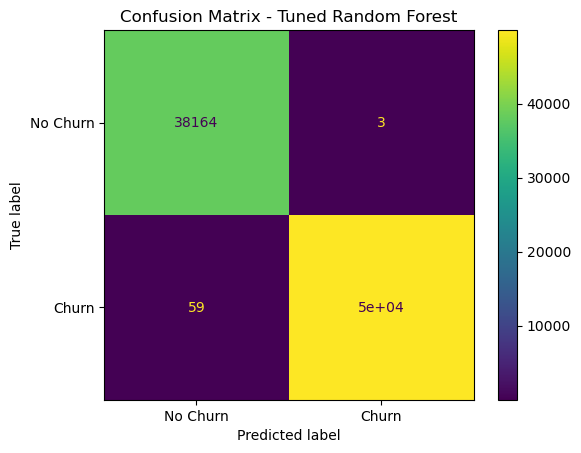

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

In [35]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Tuned Random Forest"],
    "Accuracy": [
        logistic_metrics["Accuracy"],
        rf_metrics["Accuracy"],
        accuracy_score(y_test, y_pred_best_rf)
    ],
    "Precision": [
        logistic_metrics["Precision"],
        rf_metrics["Precision"],
        precision_score(y_test, y_pred_best_rf)
    ],
    "Recall": [
        logistic_metrics["Recall"],
        rf_metrics["Recall"],
        recall_score(y_test, y_pred_best_rf)
    ],
    "F1-Score": [
        logistic_metrics["F1-Score"],
        rf_metrics["F1-Score"],
        f1_score(y_test, y_pred_best_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.893373,0.923356,0.88548,0.904021
1,Random Forest,0.999263,0.999940,0.99876,0.999350
2,Tuned Random Forest,0.999297,0.999940,0.99882,0.999380


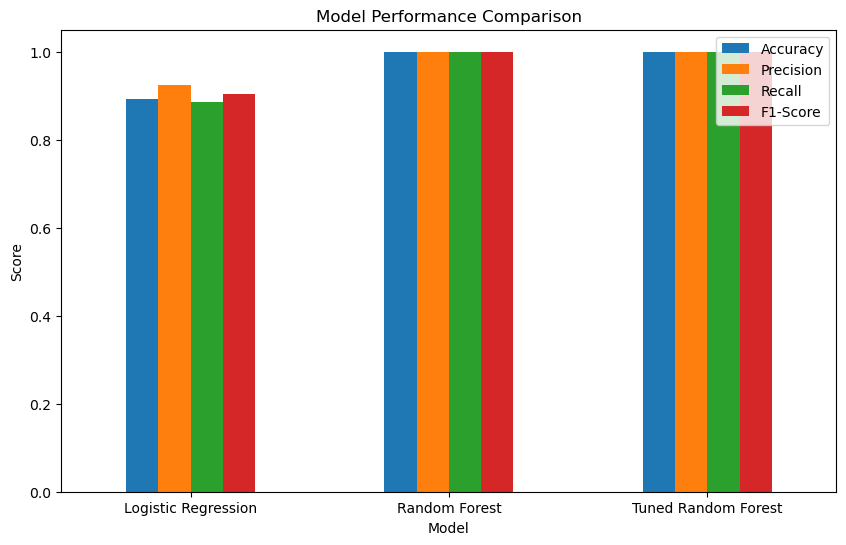

In [36]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [37]:
rf_pipeline = best_rf_model.named_steps["classifier"]
preprocessor_fitted = best_rf_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = rf_pipeline.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
3,num__Support Calls,0.292436
5,num__Total Spend,0.202712
0,num__Age,0.136792
4,num__Payment Delay,0.122560
13,cat__Contract Length_Monthly,0.106944
6,num__Last Interaction,0.048171
12,cat__Contract Length_Annual,0.021311
7,cat__Gender_Female,0.017299
14,cat__Contract Length_Quarterly,0.017290
8,cat__Gender_Male,0.016475


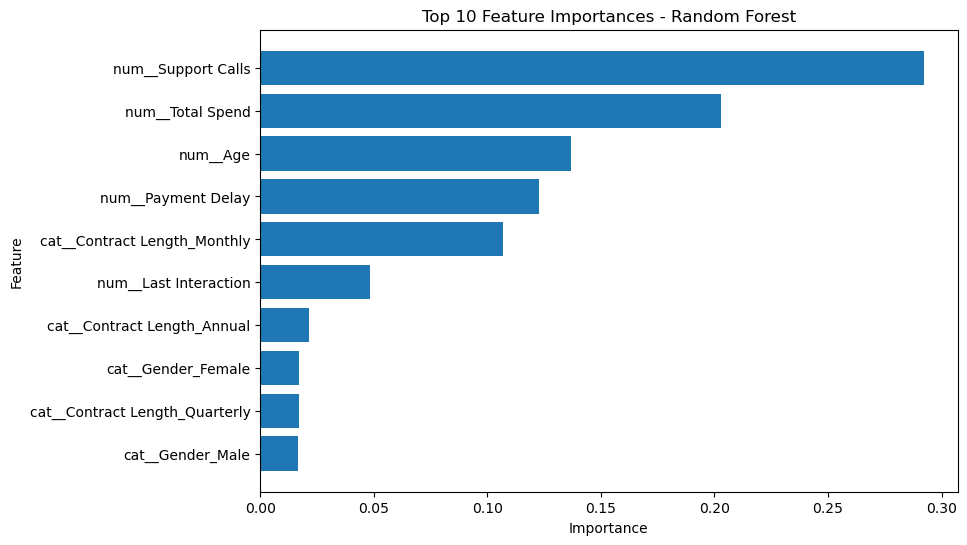

In [38]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [39]:
final_accuracy = accuracy_score(y_test, y_pred_best_rf)
final_precision = precision_score(y_test, y_pred_best_rf)
final_recall = recall_score(y_test, y_pred_best_rf)
final_f1 = f1_score(y_test, y_pred_best_rf)

print("===== FINAL MODEL RESULTS =====")
print("Model: Tuned Random Forest")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-Score : {final_f1:.4f}")
print("Best Parameters:", grid_search.best_params_)

===== FINAL MODEL RESULTS =====
Model: Tuned Random Forest
Accuracy : 0.9993
Precision: 0.9999
Recall   : 0.9988
F1-Score : 0.9994
Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


In [40]:
results.to_csv("model_comparison_results.csv", index=False)

print("Model comparison results saved successfully.")

Model comparison results saved successfully.
